# YOLO26n on SKU-110K — Full Training Run

**Config đã chốt (dựa trên pilot 3-epoch trước đó):**
- `epochs=30`, `patience=5` — model đang fine-tune từ pretrained nên hội tụ nhanh (mAP50 pilot: 0.653→0.746→0.785 chỉ trong 3 epoch). ETA ước tính ~2.2h dựa trên tốc độ ổn định đo được (~4.3 phút/epoch), fit gọn trong 1 session Kaggle.
- Giữ nguyên full trainset (8219/588/2936) — không subsample, không đổi split gốc.
- `batch=16` — pilot cho thấy VRAM creep 11.2G→13.6G/14.9GB qua 3 epoch, khá sát trần. Cell training có in nhắc theo dõi; hạ xuống 12 nếu OOM.

**⚠️ QUAN TRỌNG — tránh mất trắng khi session tự tắt:**
`/kaggle/working` bị xóa sạch khi session kết thúc (idle timeout, hết 12h, hoặc đóng tab quá lâu) **TRỪ KHI** bạn dùng **Save Version → Save & Run All (Commit)** thay vì chỉ bấm Run All thường. Commit sẽ chạy notebook nền + giữ lại toàn bộ `/kaggle/working` (weights, csv, plot) làm Output của version đó, tải lại được bất cứ lúc nào kể cả sau khi session tắt. Notebook này cũng tự zip model + kết quả lại ở mục 6 để bạn chỉ cần tải đúng 1 file.

Ultralytics tự ghi đè `last.pt`/`best.pt` sau **mỗi epoch** (không phải chỉ lúc train xong) — nên nếu kernel crash giữa chừng mà session vẫn còn sống, checkpoint tới epoch gần nhất vẫn còn trên đĩa. Rủi ro thật sự chỉ là lúc session bị hủy hẳn mà chưa commit.

## 1. Setup môi trường

In [1]:
!pip install -U ultralytics --quiet

import ultralytics
ultralytics.checks()

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.6/8062.4 GB disk)


In [2]:
import torch

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    raise RuntimeError("Chưa bật GPU — vào Settings (bên phải) > Accelerator > chọn GPU rồi chạy lại.")

!nvidia-smi

torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.6
Mon Aug 10 02:02:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        | 

## 2. Kiểm tra dataset thật (không đoán path)

Cấu trúc thật đã verify từ trang Kaggle của dataset:
```
SKU110K_fixed/
├── images/{train,val,test}
└── labels/{train,val,test}
```
Nếu path sai (đổi slug hoặc add nhầm dataset khác), cell sẽ báo lỗi rõ ràng thay vì train nhầm.

In [3]:
import os

DATA_ROOT = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"
EXPECTED = {"train": 8219, "val": 588, "test": 2936}  # theo docs.ultralytics.com/datasets/detect/sku-110k

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(
        f"Không tìm thấy {DATA_ROOT}. Kiểm tra lại: đã add dataset 'thedatasith/sku110k-annotations' "
        f"qua Add Input chưa? Chạy `os.listdir('/kaggle/input')` để xem tên slug thật."
    )

for split, expected_n in EXPECTED.items():
    img_dir = os.path.join(DATA_ROOT, "images", split)
    lbl_dir = os.path.join(DATA_ROOT, "labels", split)
    n_img = len(os.listdir(img_dir)) if os.path.isdir(img_dir) else None
    n_lbl = len(os.listdir(lbl_dir)) if os.path.isdir(lbl_dir) else None
    flag = "OK" if n_img == expected_n else "⚠️ LỆCH SỐ — kiểm tra lại trước khi train"
    print(f"{split:5s} | images={n_img} labels={n_lbl} | expected={expected_n} | {flag}")

train | images=8185 labels=8185 | expected=8219 | ⚠️ LỆCH SỐ — kiểm tra lại trước khi train
val   | images=584 labels=584 | expected=588 | ⚠️ LỆCH SỐ — kiểm tra lại trước khi train
test  | images=2920 labels=2920 | expected=2936 | ⚠️ LỆCH SỐ — kiểm tra lại trước khi train


## 3. Tạo data.yaml

Giữ nguyên split gốc — không tự chia lại.

In [4]:
yaml_content = f"""\
path: {DATA_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: object
"""

yaml_path = "/kaggle/working/sku110k.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_content)

path: /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed
train: images/train
val: images/val
test: images/test

names:
  0: object



## 4. Full training run

`epochs=30`, `patience=5` theo quyết định đã chốt. Trong lúc chạy, theo dõi cột `GPU_mem` trong log — nếu tiến sát 14.9GB (VRAM của T4) hoặc gặp lỗi CUDA OOM, dừng lại, đổi `batch=16` xuống `batch=12` rồi chạy lại từ đầu cell này.

In [5]:
import time
from ultralytics import YOLO

EPOCHS = 30
PATIENCE = 5
BATCH = 16   # hạ xuống 12 nếu thấy VRAM creep gần chạm trần hoặc gặp OOM
RUN_NAME = "sku110k_yolo26n_full"

model = YOLO("yolo26n.pt")

t0 = time.time()
results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=640,
    batch=BATCH,
    device=0,
    project="/kaggle/working/runs",
    name=RUN_NAME,
    exist_ok=True,
    workers=4,
    verbose=True,
)
elapsed_min = (time.time() - t0) / 60

print(f"\nTổng thời gian train: {elapsed_min:.1f} phút ({elapsed_min/60:.2f} giờ)")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sku110k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sku110k_yolo26n_full, nbs=64, nms

## 5. Kết quả training (trên val set)

In [6]:
import pandas as pd

run_dir = f"/kaggle/working/runs/{RUN_NAME}"
results_csv = os.path.join(run_dir, "results.csv")

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

print(f"Số epoch thực chạy: {len(df)} / {EPOCHS} đã đặt")
if len(df) < EPOCHS:
    print(f"→ Early stopping đã kích hoạt (patience={PATIENCE}) trước khi hết {EPOCHS} epoch.")

last_row = df.iloc[-1]
print("\nMetrics epoch cuối cùng (val set):")
for col in df.columns:
    if "mAP" in col or "precision" in col.lower() or "recall" in col.lower():
        print(f"  {col}: {last_row[col]:.4f}")

Số epoch thực chạy: 30 / 30 đã đặt

Metrics epoch cuối cùng (val set):
  metrics/precision(B): 0.8889
  metrics/recall(B): 0.8149
  metrics/mAP50(B): 0.8674
  metrics/mAP50-95(B): 0.5226


## 6. Lưu model + kết quả

Zip toàn bộ weights + report vào 1 file duy nhất trong `/kaggle/working`, để nếu commit hoặc tải thủ công thì chỉ cần 1 file, không sợ quên sót.

In [7]:
import shutil

archive_path = "/kaggle/working/sku110k_yolo26n_results"
shutil.make_archive(archive_path, "zip", run_dir)

size_mb = os.path.getsize(archive_path + ".zip") / 1e6
print(f"Đã lưu: {archive_path}.zip ({size_mb:.1f} MB)")
print(f"Bao gồm: weights/best.pt, weights/last.pt, results.csv, results.png, confusion_matrix.png, args.yaml, ...")
print("\n→ Nếu chưa bấm 'Save & Run All (Commit)', tải file zip này về máy NGAY qua panel Output bên phải, "
      "đừng đợi — session có thể tự tắt bất cứ lúc nào do idle timeout.")

Đã lưu: /kaggle/working/sku110k_yolo26n_results.zip (22.4 MB)
Bao gồm: weights/best.pt, weights/last.pt, results.csv, results.png, confusion_matrix.png, args.yaml, ...

→ Nếu chưa bấm 'Save & Run All (Commit)', tải file zip này về máy NGAY qua panel Output bên phải, đừng đợi — session có thể tự tắt bất cứ lúc nào do idle timeout.


## 7. Đánh giá trên test set thật (không phải val set)

Val set (588 ảnh) đã được dùng gián tiếp trong lúc train để quyết early-stopping — không phải số "sạch" 100%. Test set (2936 ảnh) chưa từng được model hay quá trình train chạm tới, nên đây mới là số đại diện đúng cho hiệu năng thật.

In [8]:
best_model = YOLO(f"{run_dir}/weights/best.pt")

test_metrics = best_model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    project="/kaggle/working/runs",
    name=f"{RUN_NAME}_test_eval",
    exist_ok=True,
    plots=True,   # bắt Ultralytics vẽ confusion_matrix.png + các plot khác
)

print("\n=== Metrics trên TEST set (2936 ảnh, chưa từng dùng lúc train) ===")
print(f"Precision (P)     : {test_metrics.box.mp:.4f}")
print(f"Recall (R)        : {test_metrics.box.mr:.4f}")
print(f"mAP50             : {test_metrics.box.map50:.4f}")
print(f"mAP50-95          : {test_metrics.box.map:.4f}")

test_eval_dir = f"/kaggle/working/runs/{RUN_NAME}_test_eval"

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.2±0.2 ms, read: 19.9±6.4 MB/s, size: 1696.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels/test... 2920 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2920/2920 79.4it/s 36.8s0.1sss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 183/183 1.8it/s 1:430.2sss
                   all       2920     429411      0.892      0.828      0.888      0.536
Speed: 0.7ms preprocess, 4.7ms inference, 0

**Lưu ý về "accuracy":** object detection không có 1 con số "accuracy" chuẩn như classification — vì mỗi ảnh có hàng trăm object cần vừa detect đúng vị trí (box) vừa đúng có/không (không đúng nhãn vì chỉ 1 class). Precision/Recall/mAP ở trên là cách đo chuẩn, đúng bản chất, và có nguồn (Ultralytics `box.map`/`box.mp`/`box.mr` — xem [reference](https://docs.ultralytics.com/reference/utils/metrics/)) thay vì gộp lại thành 1 con số "accuracy" dễ gây hiểu nhầm.

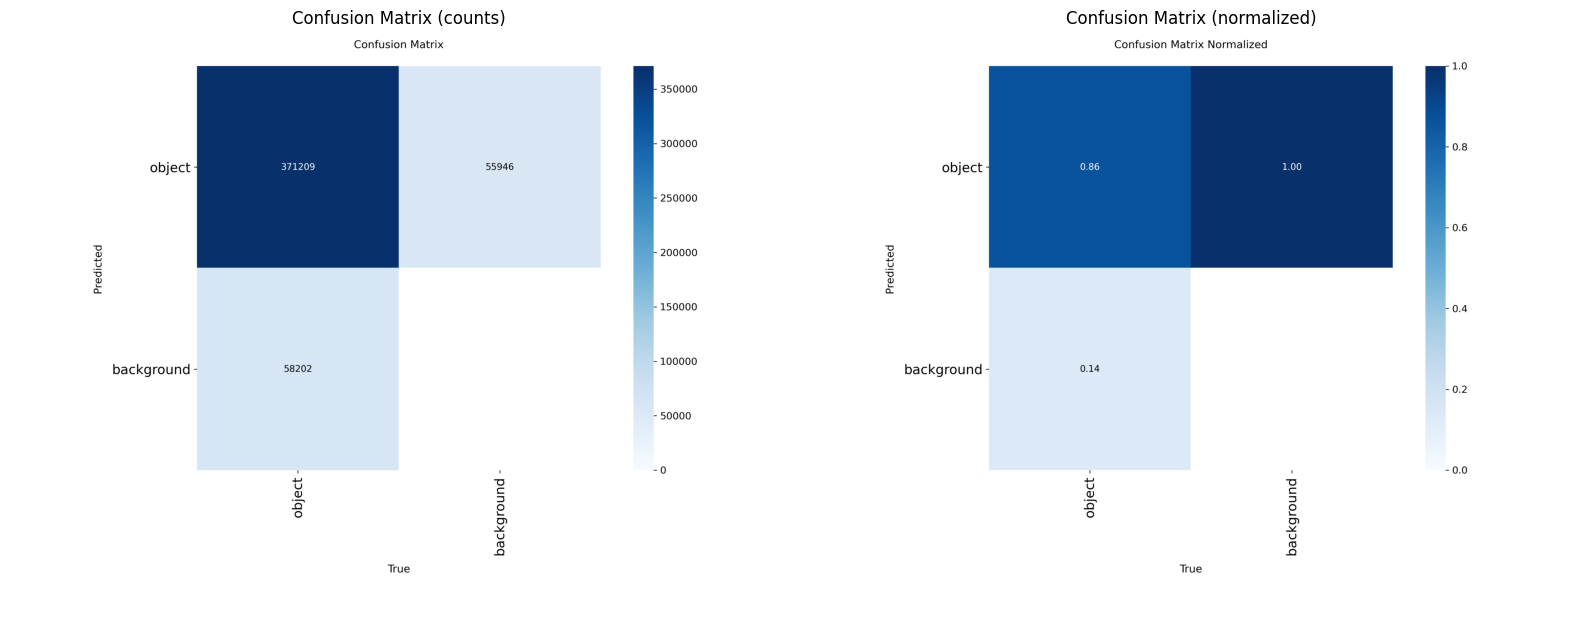

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

cm_path = os.path.join(test_eval_dir, "confusion_matrix.png")
cm_norm_path = os.path.join(test_eval_dir, "confusion_matrix_normalized.png")

if os.path.isfile(cm_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(Image.open(cm_path))
    axes[0].set_title("Confusion Matrix (counts)")
    axes[0].axis("off")
    axes[1].imshow(Image.open(cm_norm_path))
    axes[1].set_title("Confusion Matrix (normalized)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Không thấy confusion matrix ở {cm_path} — kiểm tra lại test_eval_dir.")

## 8. Random 5 ảnh test set — coi bằng mắt

So predicted box count vs ground-truth label count mỗi ảnh — đây chỉ là proxy nhanh để coi bằng mắt (không check khớp IoU từng box), không thay thế cho mAP ở mục 7.

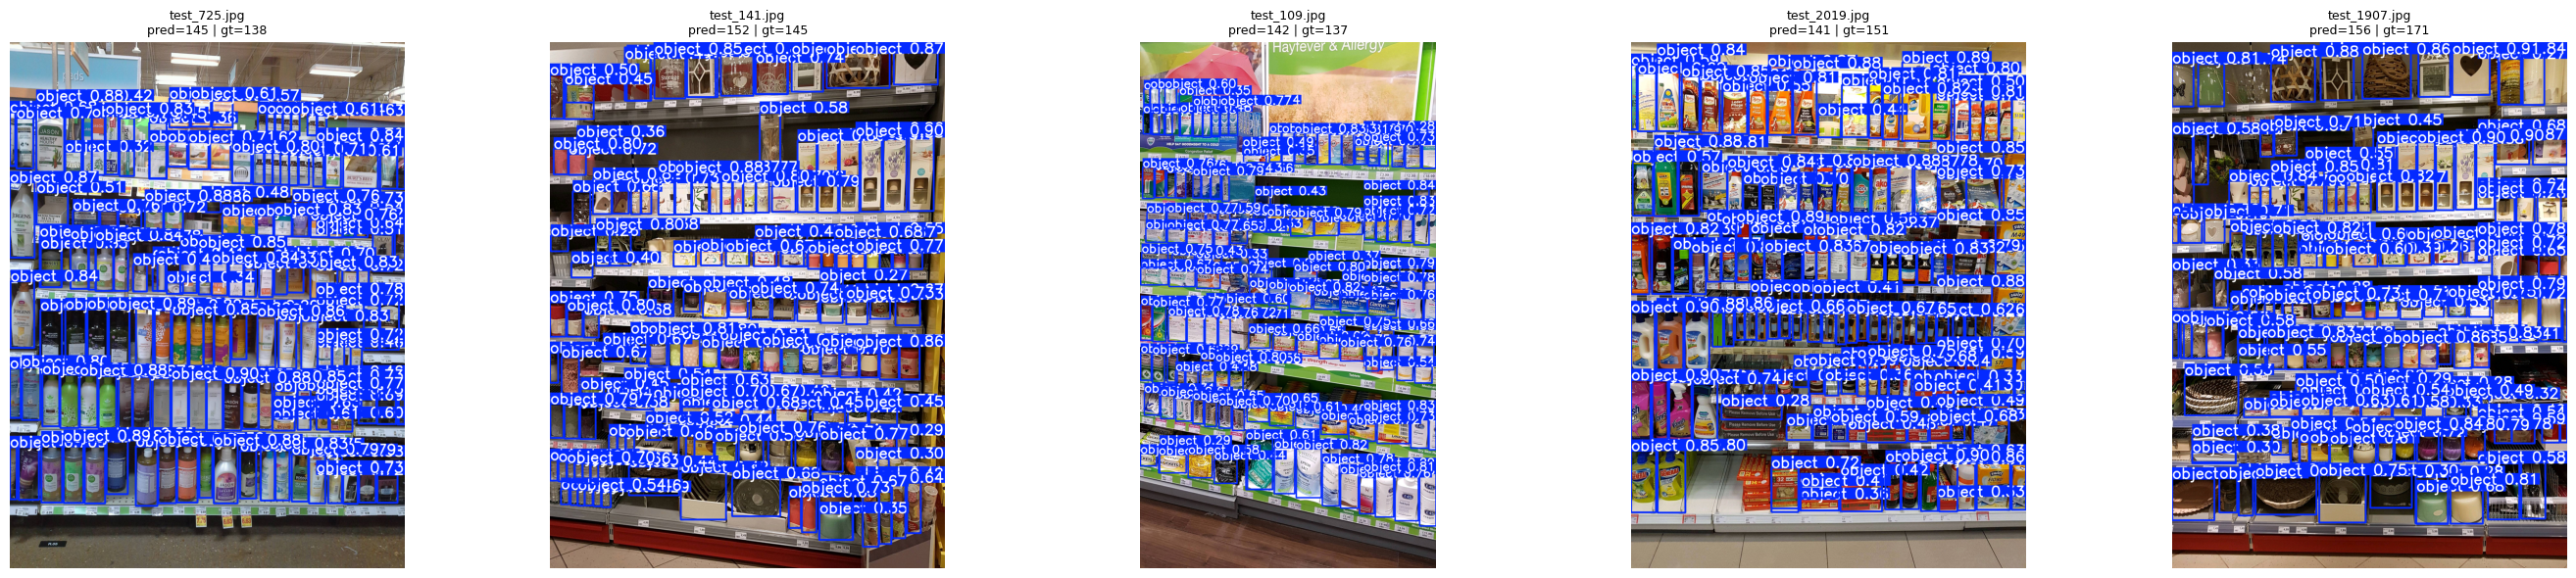

Đã lưu /kaggle/working/sample_predictions.png


In [10]:
import random
import glob

test_img_dir = os.path.join(DATA_ROOT, "images", "test")
test_lbl_dir = os.path.join(DATA_ROOT, "labels", "test")

all_test_imgs = sorted(glob.glob(os.path.join(test_img_dir, "*.jpg")))
random.seed(42)  # đổi seed nếu muốn coi bộ ảnh khác
sample_imgs = random.sample(all_test_imgs, 5)

fig, axes = plt.subplots(1, 5, figsize=(28, 6))

for ax, img_path in zip(axes, sample_imgs):
    pred = best_model.predict(img_path, imgsz=640, conf=0.25, verbose=False)[0]
    annotated_bgr = pred.plot()
    annotated_rgb = annotated_bgr[..., ::-1]

    fname = os.path.basename(img_path)
    lbl_path = os.path.join(test_lbl_dir, fname.rsplit(".", 1)[0] + ".txt")
    gt_count = sum(1 for _ in open(lbl_path)) if os.path.isfile(lbl_path) else None
    pred_count = len(pred.boxes)

    ax.imshow(annotated_rgb)
    ax.set_title(f"{fname}\npred={pred_count} | gt={gt_count}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/sample_predictions.png", dpi=150)
plt.show()

print("Đã lưu /kaggle/working/sample_predictions.png")

## 9. Bước tiếp theo

Trước khi swap checkpoint production (`runs/train_1a/n_2000/weights/best.pt`, YOLOv8n hiện tại: precision=0.758/recall=0.818):

1. So Precision/Recall ở mục 7 (test set, đo đúng chuẩn) với baseline production — không so với số val ở mục 5.
2. Nếu thắng rõ baseline: smoke-test `YOLO("best.pt").predict(device="mps")` trên máy M4 trước — MPS compatibility cho kiến trúc dual-head NMS-free của YOLO26 chưa được xác nhận.
3. Nhớ **Save & Run All (Commit)** nếu chưa làm, hoặc tải `sku110k_yolo26n_results.zip` từ mục 6 về máy trước khi rời notebook.